## Bootstrap Analysis: CT Profile Learnability on Real GO Terms (brainsc_reallabels)

In [3]:
import pandas as pd
import os

BOOTSTRAP_DIR = '/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/ctProfilePipeline/data/brainsc_reallabels'

dfs = []
for b in range(1, 11):
    path = os.path.join(BOOTSTRAP_DIR, str(b), 'EGAD', 'brain_profiles_EGAD.csv')
    tmp = pd.read_csv(path, index_col=0).reset_index()
    tmp['bootstrap'] = b
    dfs.append(tmp)

df_boot = pd.concat(dfs, ignore_index=True)

# Mean AUC per GO term across 10 bootstraps
agg_ct = df_boot.groupby('index')['auc'].mean().reset_index()
agg_ct = agg_ct.rename(columns={'auc': 'auc_ct'})
agg_ct

,index,auc_ct
0,GO:0000045,0.576898
1,GO:0000070,0.516198
2,GO:0000077,0.507225
3,GO:0000079,0.472712
4,GO:0000082,0.473176
...,...,...
1391,GO:2001237,0.477024
1392,GO:2001238,0.409342
1393,GO:2001240,0.495482
1394,GO:2001243,0.502328


/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 3 x 2 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/scatter_ct_vs_mgc.png
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 3 x 2 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/scatter_ct_vs_mgc.pdf


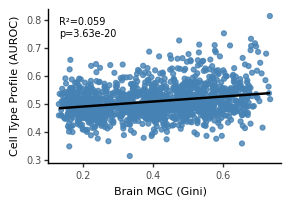

<ggplot: (8777221164508)>

In [4]:
from plotnine import *
from scipy.stats import pearsonr
import numpy as np

mgc = pd.read_csv('/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/analysis/PaperFigs/MGC/data/GO_curations_with_mgcs.csv')
mgc_ct = agg_ct.merge(mgc[['id', 'mgc_gini']], left_on='index', right_on='id').drop(columns='id')

r, pval = pearsonr(mgc_ct['mgc_gini'], mgc_ct['auc_ct'])
r2 = r**2
label = f'R²={r2:.3f}\np={pval:.2e}'

p = (
    ggplot(mgc_ct, aes(x='mgc_gini', y='auc_ct'))
    + geom_point(size=1.5, alpha=0.8, color='steelblue')
    + stat_smooth(method='lm', color='black', size=1, se=False)
    + annotate('text', x=mgc_ct['mgc_gini'].min(), y=mgc_ct['auc_ct'].max(),
               label=label, ha='left', va='top', size=7)
    + labs(
        x='Brain MGC (Gini)',
        y='Cell Type Profile (AUROC)'
    )
    + theme_classic()
    + theme(
        text=element_text(size=8),
        axis_text_x=element_text(size=7),
        axis_text_y=element_text(size=7),
        figure_size=(3, 2)
    )
)

p.save('results/scatter_ct_vs_mgc.png', dpi=300)
p.save('results/scatter_ct_vs_mgc.pdf', dpi=300)
p

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 1.5 x 1.5 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/scatter_ct_vs_comp.png
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 1.5 x 1.5 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/scatter_ct_vs_comp.pdf


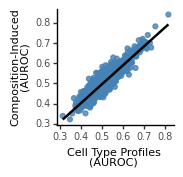

<ggplot: (8776977006562)>

In [8]:
BULK_PATH = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/realgo_allcells/master_melted_df.csv.gz"
df_bulk = pd.read_csv(BULK_PATH)

# Mean AUC per GO term across bootstraps
agg_bulk = df_bulk.groupby('index')['auc'].mean().reset_index()
agg_bulk = agg_bulk.rename(columns={'auc': 'auc_comp'})

ct_comp = agg_ct.merge(agg_bulk, on='index')

r, pval = pearsonr(ct_comp['auc_ct'], ct_comp['auc_comp'])
r2 = r**2
label = f'R²={r2:.3f}\np={pval:.2e}'

p = (
    ggplot(ct_comp, aes(x='auc_ct', y='auc_comp'))
    + geom_point(size=1.5, alpha=0.8, color='steelblue')
    + stat_smooth(method='lm', color='black', size=1, se=False)
    # + annotate('text', x=ct_comp['auc_ct'].min(), y=ct_comp['auc_comp'].max(),
            #    label=label, ha='left', va='top', size=7)
    + labs(
        x='Cell Type Profiles\n(AUROC)',
        y='Composition-Induced\n(AUROC)',
        # title = 'Performance (AUROC)'
    )
    + theme_classic()
    + theme(
        text=element_text(size=8),
        axis_text_x=element_text(size=7),
        axis_text_y=element_text(size=7),
        figure_size=(1.5, 1.5)
    )
)

p.save('results/scatter_ct_vs_comp.png', dpi=300)
p.save('results/scatter_ct_vs_comp.pdf', dpi=300)
p

In [6]:
rows = []
for name, x_col, y_col, df in [
    ('CT Profile vs MGC Gini', 'mgc_gini', 'auc_ct', mgc_ct),
    ('CT Profile vs Composition-Induced Co-expression', 'auc_ct', 'auc_comp', ct_comp)
]:
    r, pval = pearsonr(df[x_col], df[y_col])
    rows.append({'comparison': name, 'pearson_r': r, 'r2': r**2, 'p_value': pval})

pearson_df = pd.DataFrame(rows)
pearson_df.to_csv('results/pearson_r2.csv', index=False)
pearson_df

,comparison,pearson_r,r2,p_value
0,CT Profile vs MGC Gini,0.242718,0.058912,3.630936e-20
1,CT Profile vs Composition-Induced Co-expression,0.912989,0.833549,0.000000e+00
